In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Kernel Basic Functions

In [15]:
class Kernel():
    
    def compute_norm_f(self, Kxx, alpha):
        '''
        Input: 
            Kxx: numpy array of shape (n, n)
            alpha: numpy array of shape (n)
        Output:
            norm_f: float
        '''
        
        norm_f = np.dot(alpha,Kxx @ alpha)
        
        return norm_f
    
    def compute_prediction_train(self, Kxx, alpha):
        '''
        Input: 
            Kxx: numpy array of shape (n, n)
            alpha: numpy array of shape (n)
        Output:
            y: numpy array of shape (n)
        '''
        
        y = Kxx @ alpha
        
        return y
    
    def compute_prediction_test(self, Kxz, alpha):
        '''
        Input: 
            Kxz: numpy array of shape (n, m)
            alpha: numpy array of shape (n)
        Output:
            y: numpy array of shape (m)
        '''
        
        y = Kxz.T @ alpha
        
        return y
    
    
class GaussianKernel(Kernel):
    
    def __init__(self, sigma = 1):
        self.sigma = sigma
    
    def get_Kxx(self, X):
        '''
        Input: 
            X: numpy array of shape (n, d)
        Output:
            Kxx: gnumpy array of shape (n, n)
        '''
        
        norm_X = np.sum(X**2, axis=1)
        dot = X @ X.T
        Kxx = np.exp(-0.5 * (norm_X[:, None] + norm_X[None, :] - 2 * dot) / self.sigma**2)
        
        return Kxx
    
    def get_Kxz(self, X, Z):
        '''
        Input: 
            X: numpy array of shape (n, d)
            Z: numpy array of shape (m, d)
        Output:
            Kxz: gnumpy array of shape (n, m)
        '''
        
        norm_X = np.sum(X**2, axis=1)
        norm_Z = np.sum(Z**2, axis=1)
        dot = X @ Z.T
        Kxz = np.exp(-0.5 * (norm_X[:, None] + norm_Z[None, :] - 2 * dot) / self.sigma**2)

        return Kxz
    
class LinearKernel(Kernel):
    
    def __init__(self):
        pass
    
    def get_Kxx(self, X):
        '''
        Input: 
            X: numpy array of shape (n, d)
        Output:
            Kxx: gnumpy array of shape (n, n)
        '''
        
        Kxx = np.dot(X,X.T)
        
        return Kxx
    
    def get_Kxz(self, X, Z):
        '''
        Input: 
            X: numpy array of shape (n, d)
            Z: numpy array of shape (m, d)
        Output:
            Kxz: gnumpy array of shape (n, m)
        '''
        
        Kxz = np.dot(X,Z.T) 
        
        return Kxz

In [16]:
def center_train_gram_matrix(Kxx):
    '''
    Input:
        Kxx: numpy array of shape (n, n)
    Output:
        Kxx_c: numpy array of shape (n, n)
    '''
    
    Kxx_c = Kxx - np.mean(Kxx, axis=0, keepdims=True) - np.mean(Kxx, axis=1, keepdims=True) + np.mean(Kxx, keepdims=True)
    
    return Kxx_c

def center_test_gram_matrix(Kxx, Kxz):
    '''
    Input:
        Kxx: numpy array of shape (n, n)
        Kxz: numpy array of shape (n, m)
    Output:
        K_c: numpy array of shape (n, m)
    '''
    
    Kxz_c = Kxz - np.mean(Kxz, axis=0, keepdims=True) - np.mean(Kxx, axis=1, keepdims=True) + np.mean(Kxx, keepdims=True)
    
    return Kxz_c

# I. Kernel Ridge Regression

Ridge Regression is the standard linear regression with an l2 regularization 

\begin{equation*}
\min_{w \in \mathbb{R}^d} \frac{1}{n}\sum_{i=1}^n (\langle w, x_i \rangle - y_i)^2 + \lambda ||w||_2^2
\end{equation*}

It is very natural to write a kernel version

\begin{equation*}
\min_{f \in \mathcal{H}} \frac{1}{n}\sum_{i=1}^n ( \langle f, \phi(x_i) \rangle_\mathcal{H}  - y_i)^2 + \lambda ||f||_\mathcal{H}^2
\end{equation*}

Note that using the reproducing property this is equivalent to

\begin{equation*}
\min_{f \in \mathcal{H}} \frac{1}{n}\sum_{i=1}^n ( f(x_i) \ - y_i)^2 + \lambda ||f||_\mathcal{H}^2
\end{equation*}

By the representer theorem, any minimizer has the form
\begin{equation*}
f(\cdot) = \sum_{i=1}^n \alpha_i \, k(x_i, \cdot), 
\qquad \alpha \in \mathbb{R}^n.
\end{equation*}

Let $K \in \mathbb{R}^{n \times n}$ be the kernel matrix with entries 
$K_{ij} = k(x_i, x_j)$, and define $y = (y_1, \ldots, y_n)^\top$.  
Then
\begin{equation*}
f(x_j) = \sum_{i=1}^n \alpha_i k(x_i, x_j) = (K\alpha)_j,
\qquad 
\|f\|_{\mathcal H}^2 = \alpha^\top K \alpha.
\end{equation*}

Hence the optimization problem becomes
\begin{equation*}
\min_{\alpha \in \mathbb{R}^n} \; 
\frac{1}{n} \, \|K\alpha - y\|_2^2 + \lambda \, \alpha^\top K \alpha.
\end{equation*}

> **Question 1:** 
>
> Solve the problem above and implement the Kernel Ridge Regression

### ANSWER:

To find the optimal coefficients, we compute the gradient of the objective function with respect to $\alpha$ and set it to zero:

\begin{equation*}
\nabla_\alpha J(\alpha) = \frac{2}{n} K (K\alpha - y) + 2\lambda K \alpha = 0.
\end{equation*}

Simplifying, we obtain

\begin{equation*}
\frac{1}{n} K^2 \alpha + \lambda K \alpha = \frac{1}{n} K y.
\end{equation*}

Factoring $K$, we get

\begin{equation*}
K \left( \frac{1}{n} K + \lambda I \right)\alpha = \frac{1}{n} K y.
\end{equation*}

Assuming $K$ is invertible, we can simplify to

\begin{equation*}
\left( \frac{1}{n} K + \lambda I \right)\alpha = \frac{1}{n} y.
\end{equation*}

Hence, the closed-form solution for the Kernel Ridge Regression is

\begin{equation*}
\alpha^* = (K + n\lambda I)^{-1} y.
\end{equation*}

In [17]:
def get_alpha_KRR(Kxx: np.ndarray, y: np.ndarray, lbda: float) -> np.ndarray:
    '''
    Input:
        Kxx: numpy array of shape (n, n)
        y: numpy array of shape (n,)
        lbda: float (regularization strength λ)
    Output:
        alpha: numpy array of shape (n,)
    '''
    
    n = Kxx.shape[0]
    A = Kxx + n * lbda * np.eye(n)
    alpha = np.linalg.solve(A, y)
    
    return alpha

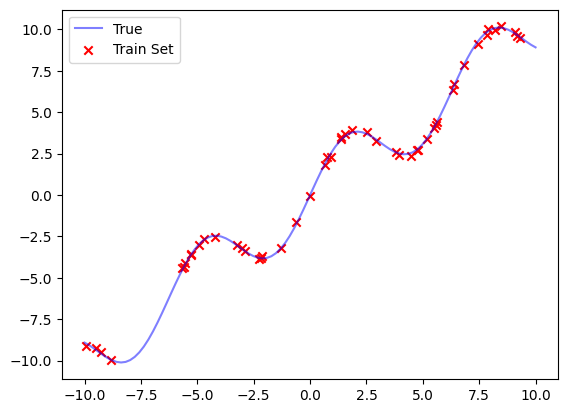

In [18]:
f = lambda x: 2*np.sin(x)+x

n  = 50
m = 100

X = np.random.uniform(-10, 10, n)
y = f(X) + np.random.normal(0, 0.1, n)
Z = np.linspace(-10, 10, m)

plt.figure()
plt.plot(Z, f(Z), color = 'blue', label = 'True', alpha = 0.5)
plt.scatter(X, y, color = 'red', label = 'Train Set', marker='x')
plt.legend()
plt.show()

X = X.reshape(-1, 1)
Z = Z.reshape(-1, 1)

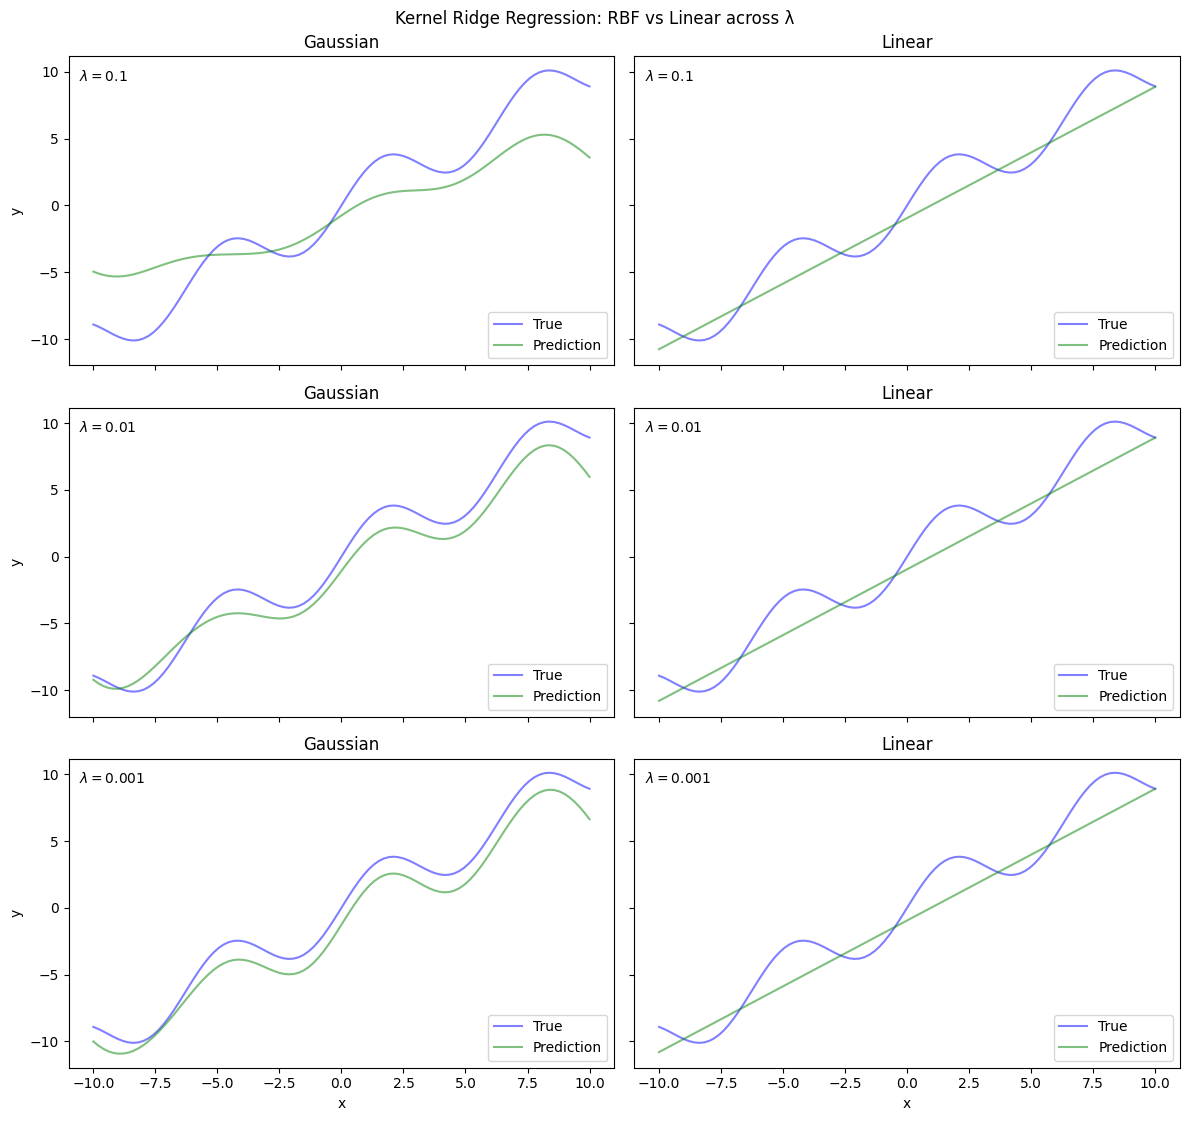

In [19]:
lambdas = [0.1, 0.01, 0.001]
sigma = 2.0  # for Gaussian (RBF) kernel


kernels = {
    'Gaussian': GaussianKernel(sigma=sigma),
    'Linear': LinearKernel(),
}


fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12), sharex=True, sharey=True)
fig.suptitle('Kernel Ridge Regression: RBF vs Linear across λ', y=0.93)

for col, (kname, kernel) in enumerate(kernels.items()):
    for row, lbda in enumerate(lambdas):
        ax = axes[row, col]

        # Compute Gram matrices
        Kxx = kernel.get_Kxx(X)
        Kxz = kernel.get_Kxz(X, Z)

        # Center in RKHS
        Kxx_c = center_train_gram_matrix(Kxx)
        Kxz_c = center_test_gram_matrix(Kxx, Kxz)

        # Replace with centered
        Kxx = Kxx_c
        Kxz = Kxz_c

        # Solve for alpha and predict
        alpha = get_alpha_KRR(Kxx, y, lbda)
        Y_pred = kernel.compute_prediction_test(Kxz, alpha)


        ax.plot(Z, f(Z), color='blue', label='True', alpha=0.5)
        ax.plot(Z, Y_pred, color='green', label='Prediction', alpha=0.5)

        if kname.startswith("RBF"):
            ax.set_title(f'{kname} (σ={sigma})')
        else:
            ax.set_title(f'{kname}')


        ax.text(0.02, 0.92, rf'$\lambda={lbda}$', transform=ax.transAxes)

        if col == 0:
            ax.set_ylabel('y')
        if row == len(lambdas) - 1:
            ax.set_xlabel('x')

        ax.legend(loc='best')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


> **Question 2:** 
>
> What is the effect of the regularization parameter $\lambda$?   What happens when you change $\sigma$ in the plots above?

### ANSWER:

The regularization parameter λ acts as a complexity control: when it is large, the model is strongly regularized and produces smoother predictions (underfitting), while a small λ makes the model more flexible but also more sensitive to noise (overfitting). 

The parameter σ of the RBF kernel determines the scale of similarity: a small σ makes the kernel very local and the model may overfit the data, whereas a large σ leads to an overly smooth model, close to a linear function (underfitting).

> **Question 3:** 
>
> Propose a numerical solver to this optimization problem instead of the closed form solution. Compare both approaches.

### ANSWER:


In [20]:
def fit_alpha(
    Kxx: np.ndarray,
    y: np.ndarray,
    lbda: float,
    lr: float = 1e-2,
    epochs: int = 2000,
) -> tuple[np.ndarray, list[float]]:
    n = Kxx.shape[0]
    alpha = np.zeros(n, dtype=Kxx.dtype)
    history = []

    #To-do: alpha and history using gradient based method
    #history should contain the objective value at each epoch for plotting

    for t in range(epochs):
        # Gradient of the objective function:
        grad = (2 / n) * Kxx @ (Kxx @ alpha - y) + 2 * lbda * Kxx @ alpha
        
        # Gradient descent update:
        alpha -= lr * grad

        # Compute objective for monitoring:
        loss = (1 / n) * np.linalg.norm(Kxx @ alpha - y)**2 + lbda * alpha.T @ Kxx @ alpha
        history.append(loss)

    return alpha, history


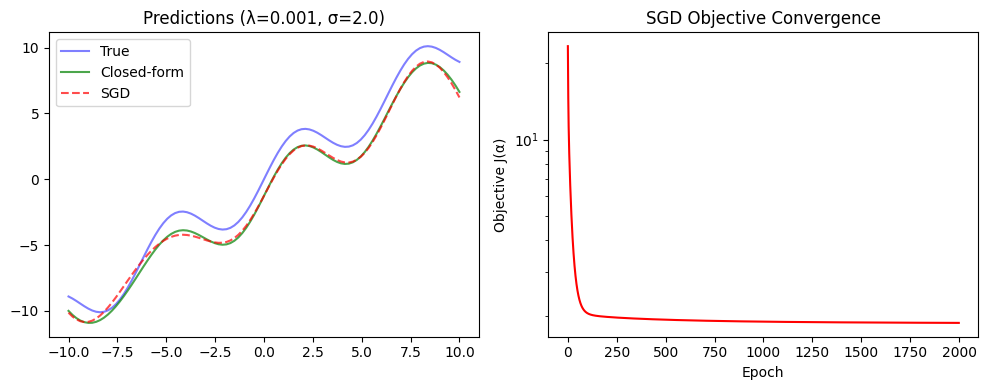

‖α_sgd - α_closed‖ = 1.800e+02


In [21]:
def compare_closed_vs_sgd(Kxx, Kxz, y, Z, kernel, lbda=1e-2):
    # Closed-form
    alpha_closed = get_alpha_KRR(Kxx, y, lbda)
    Y_pred_closed = kernel.compute_prediction_test(Kxz, alpha_closed)

    # SGD
    alpha_sgd, history = fit_alpha(Kxx, y, lbda, lr=5e-2, epochs=2000)
    Y_pred_sgd = kernel.compute_prediction_test(Kxz, alpha_sgd)


    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.title(f"Predictions (λ={lbda}, σ={kernel.sigma if hasattr(kernel, 'sigma') else 'N/A'})")
    plt.plot(Z, f(Z), color='blue', label='True', alpha=0.5)
    plt.plot(Z, Y_pred_closed, color='green', label='Closed-form', alpha=0.7)
    plt.plot(Z, Y_pred_sgd, color='red', linestyle='--', label='SGD', alpha=0.7)
    plt.legend()

    plt.subplot(1,2,2)
    plt.title("SGD Objective Convergence")
    plt.plot(history, color='red')
    plt.xlabel("Epoch")
    plt.ylabel("Objective J(α)")
    plt.yscale("log")

    plt.tight_layout()
    plt.show()

    diff = np.linalg.norm(alpha_sgd - alpha_closed)
    print(f"‖α_sgd - α_closed‖ = {diff:.3e}")

    return alpha_closed, alpha_sgd


# --- Hyperparameters ---
sigma = 2.0
lbda = 1e-3

# --- Build Gaussian kernel and Gram matrices ---
kernel = GaussianKernel(sigma=sigma)
Kxx = kernel.get_Kxx(X)        # (n x n)
Kxz = kernel.get_Kxz(X, Z)     # (n x m)

# --- Center in RKHS (train then test) ---
Kxx_c = center_train_gram_matrix(Kxx)
Kxz_c = center_test_gram_matrix(Kxx, Kxz)

# --- Compare closed-form vs SGD (uses your get_alpha_KRR) ---
alpha_closed, alpha_sgd = compare_closed_vs_sgd(
    Kxx=Kxx_c,
    Kxz=Kxz_c,
    y=y,
    Z=Z,
    kernel=kernel,
    lbda=lbda
)

### ANSWER:

Both the closed-form and gradient descent approaches yield nearly identical predictions, confirming that the numerical method converges to the same optimum. The closed-form solution is exact and faster for small datasets but requires costly matrix inversion. In contrast, gradient descent is slower and approximate but scales better for large datasets and avoids inversion, making it more practical in high dimensions.

> **Question 4:** 
>
> For a fixed $\lambda$, plot the MSE error varying the size $n$ of training points. Also, for a fixed $n$, plot the test error vs $1/\lambda$.  Interpret the results


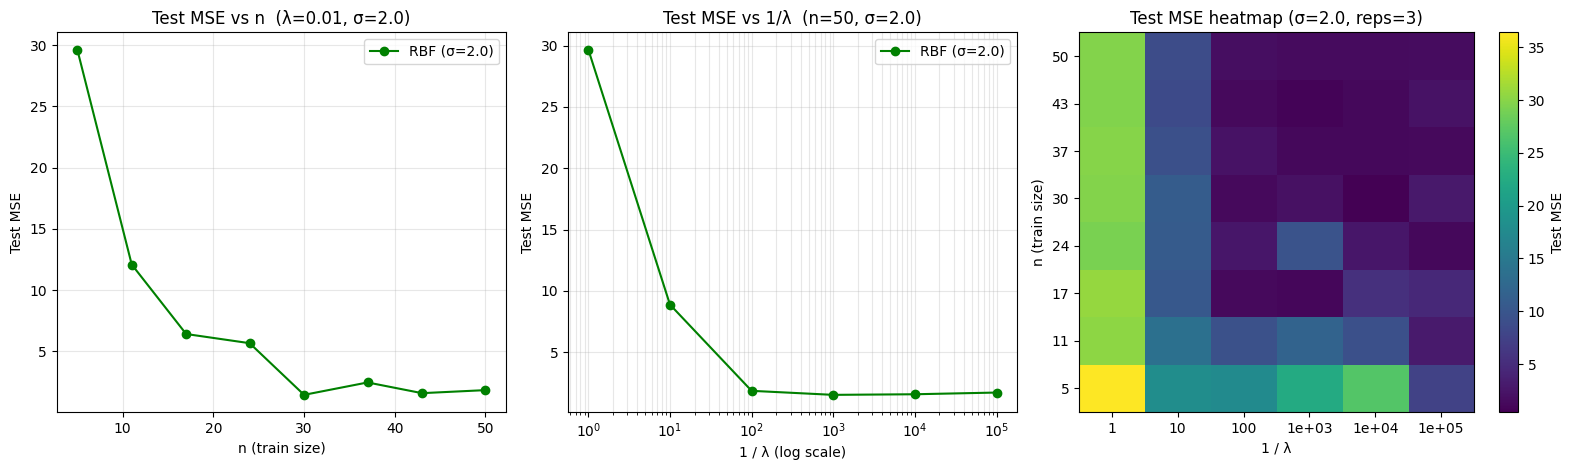

In [22]:
lambdas = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
sigma = 2.0                
lambda_fixed = 0.01       
reps = 3                   
kernel = GaussianKernel(sigma=sigma)

y_true_Z = f(Z).reshape(-1)

def krr_test_mse(X_tr, y_tr, Z, y_true_Z, kernel, lbda):
    """Train KRR on (X_tr, y_tr); return MSE on separate test grid Z with y_true_Z=f(Z)."""
    Kxx = kernel.get_Kxx(X_tr)
    Kxz = kernel.get_Kxz(X_tr, Z)
    # Center in RKHS
    Kxx_c = center_train_gram_matrix(Kxx)
    Kxz_c = center_test_gram_matrix(Kxx, Kxz)
    # Fit + predict
    alpha = get_alpha_KRR(Kxx_c, y_tr, lbda)
    y_pred = kernel.compute_prediction_test(Kxz_c, alpha).reshape(-1)
    return float(np.mean((y_true_Z - y_pred) ** 2))

# -----------------------------
# 1) Test MSE vs n (λ fixed)
# -----------------------------
rng = np.random.default_rng(0)
n_max = len(X)
ns = np.unique(np.linspace(max(5, n_max // 10), n_max, 8, dtype=int))

mses_vs_n = []
for n_tr in ns:
    fold_mses = []
    for _ in range(reps):
        idx = rng.choice(n_max, size=n_tr, replace=False)
        X_tr = X[idx]; y_tr = y[idx]
        fold_mses.append(krr_test_mse(X_tr, y_tr, Z, y_true_Z, kernel, lambda_fixed))
    mses_vs_n.append(np.mean(fold_mses))

# -----------------------------
# 2) Test MSE vs 1/λ (n fixed)
# -----------------------------
n_fixed = n_max  
X_tr_fixed = X[:n_fixed]
y_tr_fixed = y[:n_fixed]

inv_lambdas = np.array([1.0 / lb for lb in lambdas])
mses_vs_lambda = np.array([
    krr_test_mse(X_tr_fixed, y_tr_fixed, Z, y_true_Z, kernel, lb)
    for lb in lambdas
])

order = np.argsort(inv_lambdas)
inv_lambdas_sorted = inv_lambdas[order]
mses_vs_lambda_sorted = mses_vs_lambda[order]

# -----------------------------
# 3) Test MSE heatmap over (n, 1/λ)
# -----------------------------
lambdas_plot = np.array(lambdas)[order]
inv_lambdas_plot = inv_lambdas_sorted

errors_test = np.zeros((len(ns), len(lambdas_plot)), dtype=float)
for i, n_tr in enumerate(ns):
    for j, lb in enumerate(lambdas_plot):
        fold_mses = []
        for _ in range(reps):
            idx = rng.choice(n_max, size=n_tr, replace=False)
            X_tr = X[idx]; y_tr = y[idx]
            fold_mses.append(krr_test_mse(X_tr, y_tr, Z, y_true_Z, kernel, lb))
        errors_test[i, j] = np.mean(fold_mses)



# Plots
fig = plt.figure(figsize=(16, 4.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.1])
ax_n   = fig.add_subplot(gs[0, 0])
ax_lmb = fig.add_subplot(gs[0, 1])
ax_hm  = fig.add_subplot(gs[0, 2])

ax_n.plot(ns, mses_vs_n, marker='o', color='green', label=f'RBF (σ={sigma})')
ax_n.set_title(f"Test MSE vs n  (λ={lambda_fixed}, σ={sigma})")
ax_n.set_xlabel("n (train size)")
ax_n.set_ylabel("Test MSE")
ax_n.grid(True, alpha=0.3)
ax_n.legend()


ax_lmb.plot(inv_lambdas_sorted, mses_vs_lambda_sorted, marker='o', color='green', label=f'RBF (σ={sigma})')
ax_lmb.set_xscale('log')
ax_lmb.set_title(f"Test MSE vs 1/λ  (n={n_fixed}, σ={sigma})")
ax_lmb.set_xlabel("1 / λ (log scale)")
ax_lmb.set_ylabel("Test MSE")
ax_lmb.grid(True, which='both', alpha=0.3)
ax_lmb.legend()

im = ax_hm.imshow(errors_test, aspect='auto', origin='lower')
ax_hm.set_title(f"Test MSE heatmap (σ={sigma}, reps={reps})")
ax_hm.set_ylabel("n (train size)")
ax_hm.set_xlabel("1 / λ")
ax_hm.set_yticks(np.arange(len(ns)))
ax_hm.set_yticklabels([str(n) for n in ns])
ax_hm.set_xticks(np.arange(len(inv_lambdas_plot)))
ax_hm.set_xticklabels([f"{val:.3g}" for val in inv_lambdas_plot])
cbar = plt.colorbar(im, ax=ax_hm)
cbar.set_label("Test MSE")

plt.tight_layout()
plt.show()

### ANSWER:

When the number of training samples n increases, the test error (MSE) decreases. The model learns better because it has more data.

For a fixed n, when 1/λ increases (meaning less regularization), the error first goes down and then goes up again. This shows the usual balance between underfitting (too much regularization) and overfitting (too little regularization).

The heatmap confirms this relationship, with the lowest test MSE appearing in an intermediate region of λ and n. The best performance is obtained for a medium value of λ, where the model is neither too simple nor too complex.

# II. Support Vector Regression

Support Vector Regression (SVR, $\varepsilon$–insensitive)

Let the residual be  $r_i = y_i -f(x_i) - b$. From the SVR constraints

\begin{equation*}
\xi_i = \max\{0,\, r_i - \varepsilon\}, \qquad
\xi_i^\ast = \max\{0,\, -r_i - \varepsilon\}.
\end{equation*}

\begin{equation*}
\xi_i + \xi_i^\ast = \max\{0,\, |r_i| - \varepsilon\}.
\end{equation*}

Primal problem in $\mathcal{H}$:
\begin{equation*}
\min_{f\in\mathcal{H},\,b\in\mathbb{R},\,\{\xi_i,\xi_i^\ast\}}
\;\frac{1}{2}\|f\|_{\mathcal{H}}^2
\;+\; C \sum_{i=1}^n (\xi_i + \xi_i^\ast)
\end{equation*}
subject to
\begin{equation*}
y_i - f(x_i) - b \;\le\; \varepsilon + \xi_i,\qquad
f(x_i) + b - y_i \;\le\; \varepsilon + \xi_i^\ast,
\end{equation*}

\begin{equation*}
\xi_i \ge 0,\;\; \xi_i^\ast \ge 0,\qquad i=1,\ldots,n.
\end{equation*}

By the representer theorem, any minimizer has the form
\begin{equation*}
f(\cdot) = \sum_{i=1}^n (\alpha_i - \alpha_i^\ast)\,k(x_i,\cdot),
\qquad \alpha,\alpha^\ast \in \mathbb{R}^n.
\end{equation*}
Let $u=\alpha-\alpha^\ast$ and $K\in\mathbb{R}^{n\times n}$ with $K_{ij}=k(x_i,x_j)$. Then
\begin{equation*}
f(x_j)=\sum_{i=1}^n u_i\,k(x_i,x_j)=(Ku)_j,
\qquad
\|f\|_{\mathcal H}^2 = u^\top K u.
\end{equation*}

Hence the finite-dimensional dual problem is
\begin{equation*}
\max_{\alpha,\alpha^\ast\in\mathbb{R}^n}
\;-\frac{1}{2}(\alpha-\alpha^\ast)^\top K (\alpha-\alpha^\ast)
\;-\; \varepsilon\,\mathbf{1}^\top(\alpha+\alpha^\ast)
\;+\; y^\top(\alpha-\alpha^\ast)
\end{equation*}
subject to
\begin{equation*}
0 \le \alpha_i,\alpha_i^\ast \le C,\qquad
\sum_{i=1}^n (\alpha_i - \alpha_i^\ast)=0.
\end{equation*}

The predictor is
\begin{equation*}
f(x) = \sum_{i=1}^n (\alpha_i - \alpha_i^\ast)\,k(x_i,x) + b.
\end{equation*}
A valid $b$ can be recovered from KKT conditions. If $0<\alpha_i<C$,
\begin{equation*}
b = y_i - \varepsilon - \sum_{j=1}^n (\alpha_j - \alpha_j^\ast)\,k(x_j,x_i),
\end{equation*}
and if $0<\alpha_i^\ast<C$,
\begin{equation*}
b = y_i + \varepsilon - \sum_{j=1}^n (\alpha_j - \alpha_j^\ast)\,k(x_j,x_i).
\end{equation*}
(In practice $b$ is often averaged over all such support vectors.)


In [23]:
from typing import Tuple

def fit_svr_eps_primal(
    Kxx: np.ndarray,
    y: np.ndarray,
    lbda: float,
    eps: float = 0.1,
    lr_alpha: float = 5e-2,
    lr_b: float = 5e-3,
    epochs: int = 3000,
    seed: int = 0,
) -> Tuple[np.ndarray, float, list]:
    """
    Minimize: (1/n) * sum_i max(0, |y_i - (Kα)_i - b| - eps) + lbda * α^T K α
    Full-batch subgradient descent on α and b.
    """
    rng = np.random.default_rng(seed)
    n = Kxx.shape[0]
    alpha = np.zeros(n)
    b = 0.0
    history = []

    def obj(a: np.ndarray, b_: float) -> float:
        r = y - (Kxx @ a + b_)
        loss = np.maximum(0.0, np.abs(r) - eps)
        return float(np.mean(loss) + lbda * a @ (Kxx @ a))

    for _ in range(epochs):
        Ka = Kxx @ alpha
        r = y - (Ka + b)  # residuals

        # Subgradient wrt residuals for ε-insensitive loss:
        # s_i =  1  if r_i >  eps
        # s_i = -1  if r_i < -eps
        # s_i =  0  if |r_i| <= eps
        s = np.zeros_like(r)
        s[r >  eps] =  1.0
        s[r < -eps] = -1.0

        # Gradients
        # dJ/dα = -(1/n) K s + 2*lbda*Kα     (note: factor 2 on reg for symmetry with KRR)
        # dJ/db = -(1/n) 1^T s
        Ks = Kxx @ s
        Kalpha = Kxx @ alpha
        grad_alpha = -(Ks) / n + 2.0 * lbda * Kalpha
        grad_b     = -np.mean(s)

        # Updates
        alpha -= lr_alpha * grad_alpha
        b     -= lr_b     * grad_b

        history.append(obj(alpha, b))

    return alpha, b , history

def demo_krr_vs_svr(
    X: np.ndarray,
    Z: np.ndarray,
    f,  # callable
    kernel,
    lbda_krr: float = 1e-2,
    lbda_svr: float = 1e-2,
    eps: float = 0.1,
    noise_type: str = "gaussian",   
    noise_scale: float = 0.2,
    seed: int = 0,
    epochs_svr: int = 3000,
    lr_alpha: float = 5e-2,
    lr_b: float = 5e-3,
):
    rng = np.random.default_rng(seed)

    # Generate observed y with noise: y_obs = f(X) + noise
    y_true = f(X).reshape(-1)
    if noise_type.lower() == "gaussian":
        noise = rng.normal(0.0, noise_scale, size=len(X))
    elif noise_type.lower() == "uniform":
        noise = rng.uniform(-noise_scale, noise_scale, size=len(X))
    else:
        raise ValueError("noise_type must be 'gaussian' or 'uniform'")
    y_obs = y_true + noise

    # Train/test Gram matrices
    Kxx = kernel.get_Kxx(X)
    Kxz = kernel.get_Kxz(X, Z)

    # Center (train) and center test w.r.t. train stats
    Kxx_c = center_train_gram_matrix(Kxx)
    Kxz_c = center_test_gram_matrix(Kxx, Kxz)

    # -------- KRR (mean regression) --------
    alpha_krr = get_alpha_KRR(Kxx_c, y_obs, lbda_krr)
    y_pred_Z_krr = kernel.compute_prediction_test(Kxz_c, alpha_krr).reshape(-1)

    # -------- SVR (ε-insensitive) --------
    alpha_svr, b_svr, hist = fit_svr_eps_primal(
        Kxx_c, y_obs, lbda=lbda_svr, eps=eps,
        lr_alpha=lr_alpha, lr_b=lr_b, epochs=epochs_svr, seed=seed
    )
    y_pred_Z_svr = (kernel.compute_prediction_test(Kxz_c, alpha_svr) + b_svr).reshape(-1)

    # -------- Metrics --------
    y_true_Z = f(Z).reshape(-1)
    mse_krr = float(np.mean((y_true_Z - y_pred_Z_krr) ** 2))
    mse_svr = float(np.mean((y_true_Z - y_pred_Z_svr) ** 2))

    # Sparsity (support vectors): count training points with |residual| > ε
    r_tr = y_obs - (Kxx_c @ alpha_svr + b_svr)
    sv_mask = np.abs(r_tr) > eps
    sv_frac = float(np.mean(sv_mask))
    n_sv = int(sv_mask.sum())

    print(f"[{noise_type}, scale={noise_scale}]  KRR test MSE = {mse_krr:.4g} | "
          f"SVR test MSE = {mse_svr:.4g} | SVs = {n_sv}/{len(X)} ({sv_frac:.1%})")

    # -------- Plots --------
    is_univariate = (X.ndim == 2 and X.shape[1] == 1)
    plt.figure(figsize=(12, 4.8))

    ax1 = plt.subplot(1, 2, 1)
    ax1.set_title(f"KRR vs SVR ({noise_type}, ε={eps})")
    ax1.plot(Z, y_true_Z, color='blue', label='True', alpha=0.6)
    ax1.plot(Z, y_pred_Z_krr, color='green', label='KRR', alpha=0.9)
    ax1.plot(Z, y_pred_Z_svr, color='red', linestyle='--', label='SVR (ε-insensitive)', alpha=0.9)
    ax1.fill_between(Z.ravel(),
                     (y_pred_Z_svr - eps).ravel(),
                     (y_pred_Z_svr + eps).ravel(),
                     alpha=0.15, color='red', label='SVR ε-tube')
    if is_univariate:
        ax1.scatter(X[~sv_mask, 0], y_obs[~sv_mask], s=16, alpha=0.5, label='Train (inside tube)')
        ax1.scatter(X[sv_mask, 0],  y_obs[sv_mask],  s=24, alpha=0.8, label='Support vectors')
    ax1.set_xlabel("x"); ax1.set_ylabel("y")
    ax1.legend()

  
    ax2 = plt.subplot(1, 2, 2)
    ax2.set_title("SVR objective convergence")
    ax2.plot(hist)
    ax2.set_yscale('log')
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("Objective")
    plt.tight_layout()
    plt.show()

    return {
        "alpha_krr": alpha_krr,
        "alpha_svr": alpha_svr,
        "b_svr": b_svr,
        "mse_krr": mse_krr,
        "mse_svr": mse_svr,
        "sv_mask": sv_mask,
        "history_svr": hist,
    }

[gaussian, scale=0.4]  KRR test MSE = 1.913 | SVR test MSE = 6.419 | SVs = 36/50 (72.0%)


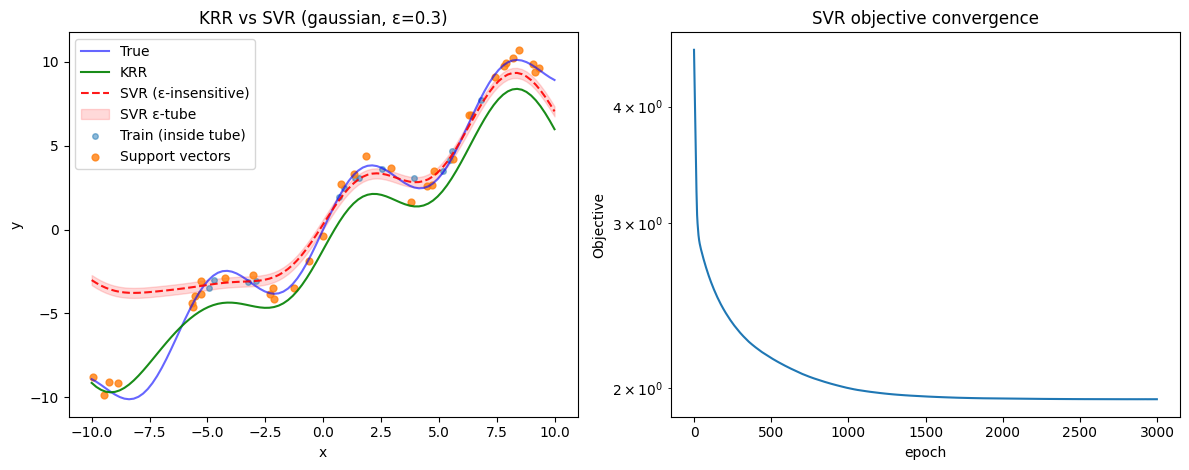

[uniform, scale=0.4]  KRR test MSE = 1.863 | SVR test MSE = 6.611 | SVs = 31/50 (62.0%)


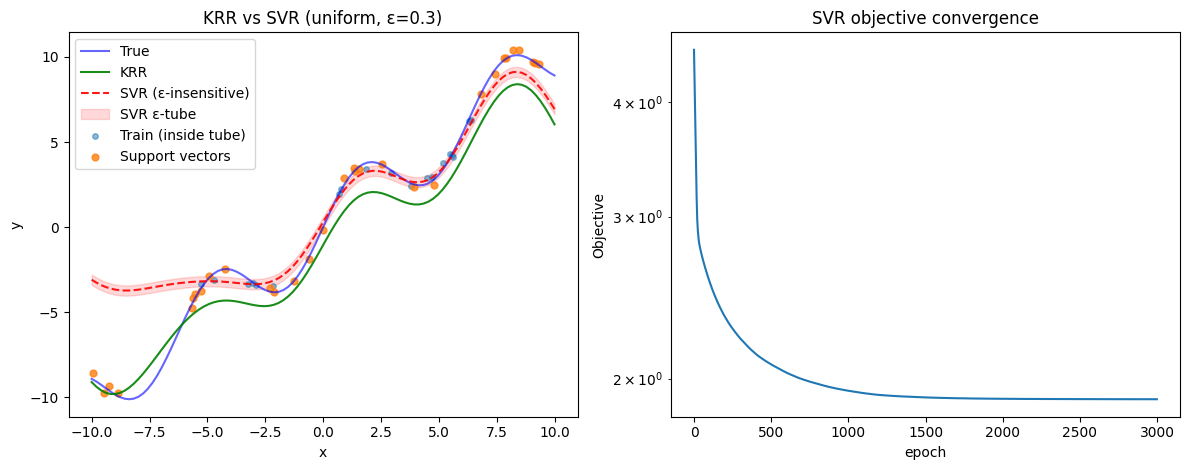

In [24]:
sigma = 2.0
kernel = GaussianKernel(sigma=sigma)

res_gauss = demo_krr_vs_svr(
    X=X, Z=Z, f=f, kernel=kernel,
    lbda_krr=1e-2, lbda_svr=1e-2, eps=0.3,
    noise_type="gaussian", noise_scale=0.4, seed=0, epochs_svr=3000
)

res_unif = demo_krr_vs_svr(
    X=X, Z=Z, f=f, kernel=kernel,
    lbda_krr=1e-2, lbda_svr=1e-2, eps=0.3,
    noise_type="uniform", noise_scale=0.4, seed=1, epochs_svr=3000
)

> **Question 5:** 
>
> What happens with the Support Vector fraction when $\varepsilon$ increases?

### ANSWER:

When ε increases, the Support Vector fraction decreases. A larger ε widens the insensitive tube, meaning that more training points fall inside this margin where errors are ignored. As a result, fewer points violate the margin and become support vectors, leading to a sparser model that is less sensitive to noise but may fit the data less precisely.

> **Question 6:** 
>
> Solve SVR for different values of ε (e.g. 0.1, 0.3, 0.5) and test MSE. What do you observe? Explain why this happens.   

### ANSWER:

We solved the SVR for different values of ε = 0.1, 0.3, and 0.5. As ε increased, the number of support vectors decreased significantly, and the test MSE slightly increased. For small ε (e.g., 0.1), the model fits the data more closely, resulting in a lower bias but higher variance. When ε becomes larger (e.g., 0.5), the ε-insensitive tube widens. This means that small errors are ignored, which reduces the number of support vectors and smooths the function. Consequently, the model becomes simpler, the variance decreases, but the bias increases, leading to a higher overall test MSE.

# III. Quantile Regression: Going beyond the mean (Bonus)

Quantile level $\tau \in (0,1)$ with pinball loss $\rho_\tau(u)$,
\begin{equation*}
\rho_\tau(u)
= u\bigl(\tau-\mathbf{1}\{u<0\}\bigr)
= \begin{cases}
\tau\,u, & u \ge 0,\\[4pt]
(\tau-1)\,u, & u < 0.
\end{cases}
\end{equation*}

Linear model (no intercept):
\begin{equation*}
\min_{w\in\mathbb{R}^d} \;\frac{1}{n}\sum_{i=1}^n \rho_\tau\!\big(y_i - \langle w,x_i\rangle\big) \;+\; \lambda \|w\|_2^2.
\end{equation*}

Kernel (RKHS) model (no intercept):
\begin{equation*}
\min_{f\in\mathcal{H}} \;\frac{1}{n}\sum_{i=1}^n \rho_\tau\!\big(y_i - f(x_i)\big) \;+\; \lambda \|f\|_{\mathcal{H}}^2.
\end{equation*}

Representer form:
\begin{equation*}
f(\cdot)=\sum_{i=1}^n \alpha_i\,k(x_i,\cdot),\qquad K_{ij}=k(x_i,x_j).
\end{equation*}

Finite-dimensional problem:
\begin{equation*}
\min_{\alpha\in\mathbb{R}^n} \;\frac{1}{n}\sum_{i=1}^n \rho_\tau\!\big(y_i - (K\alpha)_i\big) \;+\; \lambda\,\alpha^\top K \alpha.
\end{equation*}

Predictor:
\begin{equation*}
\hat{f}_\tau(x)=\sum_{i=1}^n \alpha_i^\star\,k(x_i,x).
\end{equation*}

Subgradient optimality:
\begin{equation*}
0 \in -\frac{1}{n}K\,s + 2\lambda K\alpha,
\end{equation*}

\begin{equation*}
s_i \in \partial \rho_\tau\!\big(y_i-(K\alpha)_i\big)=
\begin{cases}
\{\tau-1\}, & y_i-(K\alpha)_i<0,\\
[\tau-1,\;\tau], & =0,\\
\{\tau\}, & >0.
\end{cases}
\end{equation*}

> **Question Bonus:** 
>
> Implement Kernel Quantile Regression (KQR) and plot KQR for $\tau=[0.1, 0.5, 0.9]$. Compare the results with ridge regression. 

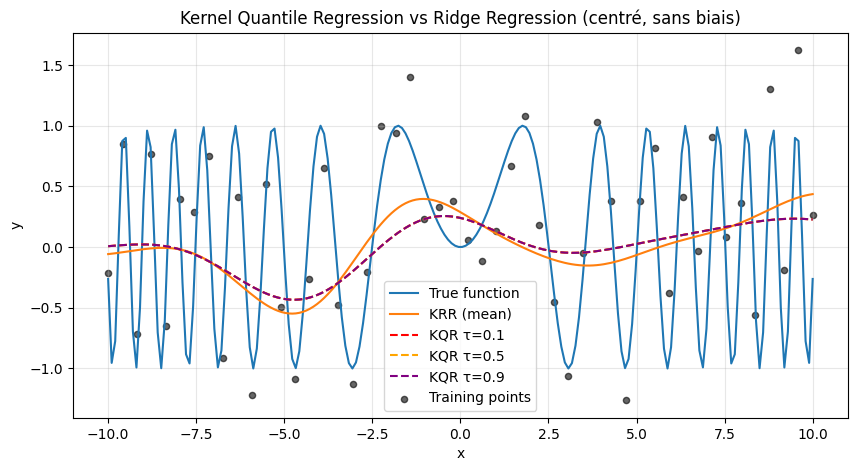

{0.1: array([ 0.00750012,  0.00978756,  0.01202592,  0.01416948,  0.01616925,
         0.01797332,  0.01952726,  0.02077468,  0.02165771,  0.02211762,
         0.0220955 ,  0.0215329 ,  0.0203726 ,  0.01855936,  0.01604066,
         0.0127675 ,  0.00869518,  0.00378406, -0.00199972, -0.00868351,
        -0.0162875 , -0.02482412, -0.03429748, -0.04470293, -0.05602665,
        -0.06824535, -0.08132612, -0.09522625, -0.10989331, -0.12526523,
        -0.14127054, -0.15782866, -0.17485043, -0.19223859, -0.20988844,
        -0.22768864, -0.245522  , -0.26326642, -0.2807959 , -0.29798161,
        -0.31469297, -0.33079887, -0.3461688 , -0.36067411, -0.37418919,
        -0.3865927 , -0.39776875, -0.40760806, -0.41600906, -0.42287894,
        -0.42813463, -0.43170372, -0.43352525, -0.4335504 , -0.43174314,
        -0.42808068, -0.42255385, -0.41516734, -0.4059398 , -0.39490383,
        -0.38210584, -0.36760576, -0.35147664, -0.3338041 , -0.3146857 ,
        -0.29423019, -0.27255661, -0.24979333,

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Pinball loss (sous-gradient)
def pinball_loss_grad(r, tau):
    """
    r = résidus = y - Kα (vecteur)
    tau = niveau de quantile (0,1)
    """
    s = np.zeros_like(r)
    s[r > 0] = tau
    s[r < 0] = tau - 1
    return s

# KQR par sous-gradient 
def fit_kqr(Kxx, y, tau=0.5, lbda=1e-2, lr=5e-3, epochs=3000, seed=0):
    """
    Minimise : (1/n) * sum_i ρ_tau(y_i - (Kα)_i) + lbda * α^T K α
    (modèle sans biais, à utiliser de préférence avec Gram centré)
    """
    rng = np.random.default_rng(seed)
    n = len(y)
    Kxx = (Kxx + Kxx.T) * 0.5
    y = y.reshape(-1)

    alpha = np.zeros(n, dtype=Kxx.dtype)
    history = []

    for _ in range(epochs):
        Ka = Kxx @ alpha
        r = y - Ka
        s = pinball_loss_grad(r, tau)
        grad = -(Kxx @ s) / n + 2.0 * lbda * (Kxx @ alpha)
        alpha -= lr * grad

        loss = (1.0 / n) * np.sum(np.where(r >= 0, tau * r, (tau - 1.0) * r)) \
               + lbda * (alpha @ (Kxx @ alpha))
        history.append(float(loss))

    return alpha, history

# Démo KQR vs KRR (cohérente)
def demo_kqr_vs_krr(X, Z, f, kernel, taus=[0.1, 0.5, 0.9],
                    lbda_kqr=1e-2, lbda_krr=1e-2, noise_scale=0.3, seed=0):
    rng = np.random.default_rng(seed)
    y_true = f(X).reshape(-1)
    noise = rng.normal(0.0, noise_scale, size=len(X))
    y_obs = (y_true + noise).astype(float, copy=False)

    Kxx = kernel.get_Kxx(X).astype(float, copy=False)
    Kxz = kernel.get_Kxz(X, Z).astype(float, copy=False)

    Kxx_c = center_train_gram_matrix(Kxx)
    Kxz_c = center_test_gram_matrix(Kxx, Kxz)  # centré par rapport au train

    alpha_krr = get_alpha_KRR(Kxx_c, y_obs, lbda=lbda_krr)
    y_pred_krr = (Kxz_c.T @ alpha_krr).reshape(-1)

    # KQR pour différents τ
    preds = {}
    for tau in taus:
        alpha_tau, _ = fit_kqr(Kxx_c, y_obs, tau=tau, lbda=lbda_kqr, lr=5e-3, epochs=3000, seed=seed)
        preds[tau] = (Kxz_c.T @ alpha_tau).reshape(-1)

    plt.figure(figsize=(10, 5))
    plt.plot(Z, f(Z), label='True function')
    plt.plot(Z, y_pred_krr, label='KRR (mean)')
    colors = ['r', 'orange', 'purple']
    for tau, color in zip(taus, colors):
        plt.plot(Z, preds[tau], linestyle='--', color=color, label=f'KQR τ={tau}')
    plt.scatter(X, y_obs, s=20, c='k', alpha=0.6, label='Training points')
    plt.xlabel('x'); plt.ylabel('y')
    plt.title('Kernel Quantile Regression vs Ridge Regression (centré, sans biais)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return preds


def f(x):
    return np.sin(0.5 * x**2)

X = np.linspace(-10, 10, 50).reshape(-1, 1)
Z = np.linspace(-10, 10, 200).reshape(-1, 1)

kernel = GaussianKernel(sigma=2.0)
demo_kqr_vs_krr(X, Z, f, kernel, taus=[0.1, 0.5, 0.9], lbda_kqr=1e-2, lbda_krr=1e-2, noise_scale=0.4)


### ANSWER:

When we apply Kernel Quantile Regression (KQR) for τ = 0.1, 0.5, and 0.9, each model predicts a different part of the data distribution.
The case τ = 0.5 corresponds to the median and behaves like Kernel Ridge Regression, which estimates the mean.
For τ = 0.1 and τ = 0.9, the model captures the lower and upper parts of the distribution, showing the spread of the data.
Compared to ridge regression, KQR is more robust to outliers and gives more information about the variability of the data.